<a href="https://colab.research.google.com/github/23031981-rkv/hbot1/blob/main/01_Linear_Regression_Classroom_Demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Regression Analysis

###Learning Goals

By the end of this class, you should be able to:

- Identify **when a problem is a regression problem.**
- Understand the difference between **a feature** and **a target**.
- Understand the **slope, intercept, and prediction line.**
- Measure prediction errors using **MAE, RMSE, and R².**
- Understand how **polynomial features** can help a linear model learn a curved relationship.
- Understand the basic workflow: **train → predict → evaluate.**

## 1. What problem are we solving?

Suppose we want to predict a student's **exam score** based on the **number of hours they studied**.

- **Input / feature ($x$):** Study hours — the input we use for prediction.
- **Output / target ($y$):** Exam score — the value we want to predict.
- Since the target is a **continuous numerical value**, this is a **regression problem**.

Linear regression tries to fit the best straight line:

$$\hat{y} = b_0 + b_1x$$

- $\hat{y}$: predicted value
- $b_0$: intercept — prediction when $x=0$
- $b_1$: slope — predicted change in $y$ for a one-unit increase in $x$



## 2. Import the tools

In [ ]:
# Data handling and plotting
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Make notebook output consistent every time it is run
np.random.seed(42)
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"figure.figsize": (8, 5), "font.size": 11})

# A small, consistent color palette for all graphs
BLUE = "#2563EB"
ORANGE = "#F97316"
GREEN = "#16A34A"
RED = "#DC2626"
PURPLE = "#7C3AED"



# Machine-learning tools
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, PolynomialFeatures

Setup complete — the notebook is ready.


## 3. Create a tiny dataset

In [ ]:
# Each list has 12 values: one pair for each student
data = pd.DataFrame({
    "study_hours": [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12],
    "exam_score":  [42, 47, 50, 55, 57, 63, 66, 70, 75, 78, 84, 88]
})

print("Rows and columns:", data.shape)
display(data)

Rows and columns: (12, 2)


,study_hours,exam_score
0,1,42
1,2,47
2,3,50
3,4,55
4,5,57
5,6,63
6,7,66
7,8,70
8,9,75
9,10,78


The dataset is deliberately small so every row can be understood.

**Q:** “Before fitting any model, what pattern do you expect to see?”

**A:** students who study more hours generally have higher scores, although real data rarely lies exactly on one line.

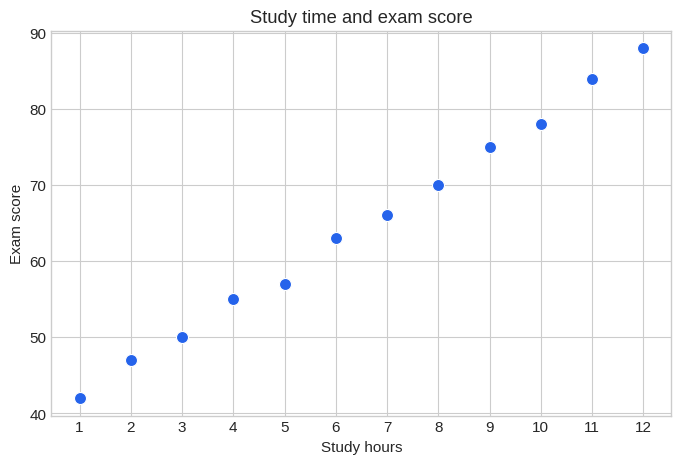

In [ ]:
# A scatter plot shows the relationship before modeling
plt.scatter(data["study_hours"], data["exam_score"],
            s=75, color=BLUE, edgecolor="white", linewidth=0.8)
plt.title("Study time and exam score")
plt.xlabel("Study hours")
plt.ylabel("Exam score")
plt.xticks(data["study_hours"])
plt.show()

## 4. Separate feature and target, then split the data

In [ ]:
# X must be a 2D table: (number of rows, number of features)
X = data[["study_hours"]]

# y is the 1D target we want to predict
y = data["exam_score"]

# Use 75% for learning and 25% for an honest final check
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

print("X shape      :", X.shape)
print("Training rows:", len(X_train))
print("Testing rows :", len(X_test))
display(pd.DataFrame({
    "test_study_hours": X_test["study_hours"],
    "actual_score": y_test
}).sort_values("test_study_hours"))

X shape      : (12, 1)
Training rows: 9
Testing rows : 3


,test_study_hours,actual_score
0,1,42
9,10,78
10,11,84


## 5. Create and train the model

In [ ]:
# Step 1: create an empty model
model = LinearRegression()

# Step 2: learn the best line from the training data
model.fit(X_train, y_train)

# The fitted line has one intercept and one slope
intercept = model.intercept_
slope = model.coef_[0]

print(f"Intercept (b₀): {intercept:.2f}")
print(f"Slope     (b₁): {slope:.2f}")
print(f"Learned equation: predicted score = {intercept:.2f} + {slope:.2f} × study hours")

Intercept (b₀): 37.86
Slope     (b₁): 4.11
Learned equation: predicted score = 37.86 + 4.11 × study hours


### What did `fit()` learn?

The model chooses the slope and intercept that minimize the **sum of squared residuals**:

$$\text{Residual} = y - \hat{y}$$

$$\text{Sum of squared residuals} = \sum_i (y_i-\hat{y}_i)^2$$

Squaring prevents positive and negative errors from cancelling and penalizes large errors more strongly.

**Interpret the slope in words:** for one additional study hour, the predicted exam score changes by approximately the printed slope value.

> The intercept is mathematically necessary, but “score at zero hours” may not be meaningful when zero lies outside the observed range.

## 6. Predict the unseen test rows

In [ ]:
# Use the learned line to predict the held-out students
y_pred = model.predict(X_test)

# Put actual and predicted values side by side
results = pd.DataFrame({
    "study_hours": X_test["study_hours"],
    "actual_score": y_test,
    "predicted_score": y_pred,
    "residual": y_test - y_pred
}).sort_values("study_hours")

display(results.round(2))

,study_hours,actual_score,predicted_score,residual
0,1,42,41.97,0.03
9,10,78,78.98,-0.98
10,11,84,83.09,0.91


## 7. Evaluate with three metrics

### Regression Evaluation Metrics

**1. Mean Absolute Error (MAE)**

$$
MAE = \frac{1}{n}\sum_{i=1}^{n}|y_i-\hat{y}_i|
$$

**2. Root Mean Squared Error (RMSE)**

$$
RMSE = \sqrt{\frac{1}{n}\sum_{i=1}^{n}(y_i-\hat{y}_i)^2}
$$

**3. R² Score**

$$
R^2 = 1-\frac{\sum_{i=1}^{n}(y_i-\hat{y}_i)^2}
{\sum_{i=1}^{n}(y_i-\bar{y})^2}
$$

Where:

- $y_i$ = actual value
- $\hat{y}_i$ = predicted value
- $\bar{y}$ = mean of actual values
- $n$ = number of observations

In [ ]:
# Average absolute error, in the original unit (score points)
mae = mean_absolute_error(y_test, y_pred)

# Root mean squared error, also in score points
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

# Proportion of target variation explained by the model
r2 = r2_score(y_test, y_pred)

metrics = pd.DataFrame({
    "Metric": ["MAE", "RMSE", "R²"],
    "Value": [mae, rmse, r2],
    "Better when": ["closer to 0", "closer to 0", "closer to 1"]
})
display(metrics.round(3))

,Metric,Value,Better when
0,MAE,0.639,closer to 0
1,RMSE,0.772,closer to 0
2,R²,0.998,closer to 1


### Metric intuition

| Metric | Plain-language meaning |
|---|---|
| **MAE** | Average size of the mistakes, ignoring direction |
| **RMSE** | Like MAE, but larger mistakes receive more weight |
| **$R^2$** | How much of the variation in the test target is explained |

For this toy example, metrics can change noticeably because the test set contains only three rows. Real projects should use more data and often cross-validation.

## 8. Visualize the fitted line and residuals

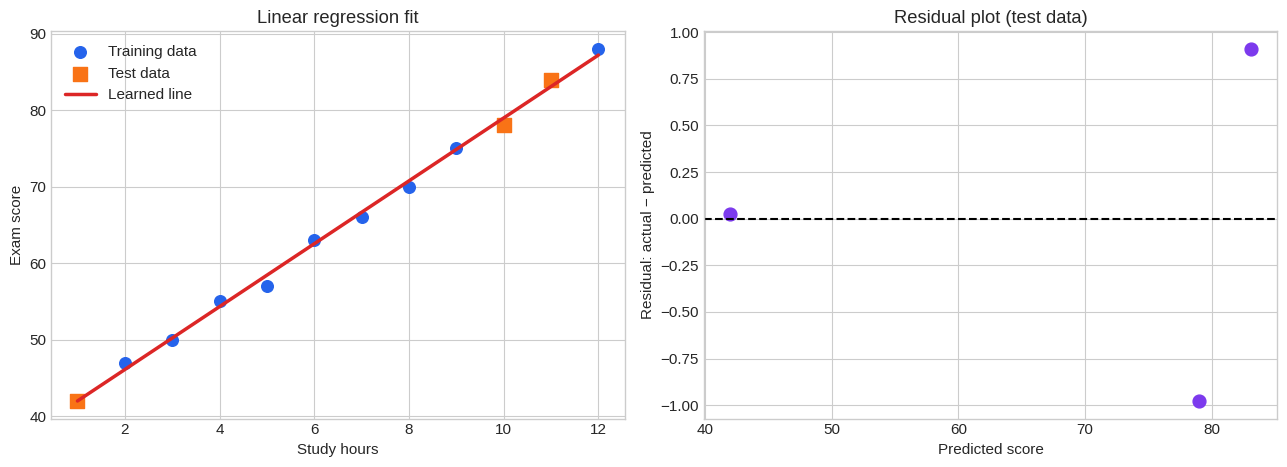

In [ ]:
# Create many x-values so the fitted line looks smooth
x_line = pd.DataFrame({"study_hours": np.linspace(1, 12, 200)})
y_line = model.predict(x_line)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.8))

# Left: observations and the learned regression line
ax1.scatter(X_train["study_hours"], y_train, s=70,color=BLUE, label="Training data")

ax1.scatter(X_test["study_hours"], y_test, s=90, marker="s",color=ORANGE, label="Test data")

ax1.plot(x_line["study_hours"], y_line, color=RED, linewidth=2.5,label="Learned line")

ax1.set(title="Linear regression fit", xlabel="Study hours", ylabel="Exam score")
ax1.legend()

# Right: residuals should be scattered around the zero line
ax2.scatter(y_pred, y_test - y_pred, s=85, color=PURPLE)
ax2.axhline(0, color="black", linestyle="--", linewidth=1.5)

ax2.set(title="Residual plot (test data)", xlabel="Predicted score", ylabel="Residual: actual − predicted")

plt.tight_layout()
plt.show()

## 9. Use the model for a new prediction

In [ ]:
new_student = pd.DataFrame({"study_hours": [7.5]})
predicted_score = model.predict(new_student)[0]

print(f"For 7.5 study hours, the predicted exam score is {predicted_score:.1f}.")

For 7.5 study hours, the predicted exam score is 68.7.


## 10. Multiple Linear Regression

When we have **more than one feature** that may help us predict the target, we can use **Multiple Linear Regression**.

For example, instead of predicting a student's exam score using only **study hours**, we can also consider **sleep hours**.

- **Feature 1:** Study hours
- **Feature 2:** Sleep hours
- **Target:** Exam score

With one feature, we learn a **line**.

With two features, the model learns a **plane** in 3D space.

### Equation

For one feature:

$$
\hat{y}=b_0+b_1x
$$

For two features:

$$
\hat{y}=b_0+b_1x_1+b_2x_2
$$

For our example:

$$
\boxed{
\hat{y}
=
b_0
+
b_1(\text{study hours})
+
b_2(\text{sleep hours})
}
$$



In [ ]:
# Add one more feature to the same tiny dataset
data_2d = data.copy()
data_2d["sleep_hours"] = [5.0, 6.0, 5.5, 6.5, 6.0, 7.0,
                          6.5, 7.5, 7.0, 8.0, 7.5, 8.0]

X_two = data_2d[["study_hours", "sleep_hours"]]
y_two = data_2d["exam_score"]

linear_pipeline = Pipeline([
    ("fill_missing", SimpleImputer(strategy="median")),
    ("scale", StandardScaler()),
    ("model", LinearRegression())
])

linear_pipeline.fit(X_two, y_two)
print("Two-feature pipeline fitted successfully.")

Two-feature pipeline fitted successfully.


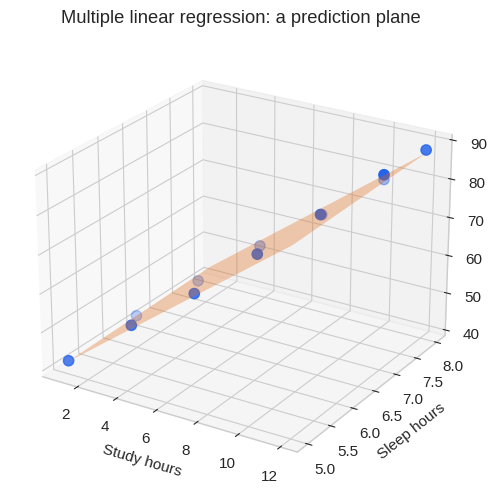

In [ ]:
# Build a grid and ask the pipeline for a prediction at every grid point
study_grid, sleep_grid = np.meshgrid(
    np.linspace(data_2d.study_hours.min(), data_2d.study_hours.max(), 25),
    np.linspace(data_2d.sleep_hours.min(), data_2d.sleep_hours.max(), 25)
)
grid = pd.DataFrame({
    "study_hours": study_grid.ravel(),
    "sleep_hours": sleep_grid.ravel()
})
score_grid = linear_pipeline.predict(grid).reshape(study_grid.shape)

# Plot the observations and the learned prediction plane
fig = plt.figure(figsize=(9, 6))
ax = fig.add_subplot(111, projection="3d")

ax.scatter(data_2d.study_hours, data_2d.sleep_hours, data_2d.exam_score, s=55, color=BLUE, label="Students")

ax.plot_surface(study_grid, sleep_grid, score_grid,alpha=0.35, color=ORANGE, edgecolor="none")

ax.set(xlabel="Study hours", ylabel="Sleep hours", zlabel="Exam score", title="Multiple linear regression: a prediction plane")

ax.view_init(elev=24, azim=-58)
plt.show()

## 11. Polynomial Regression: When a Straight Line Is Not Enough

Linear Regression assumes that the relationship between the feature and target can be represented by a **straight line**.

But sometimes the relationship is **curved**.

For example, a reaction may increase with temperature at first, reach an optimum, and then decrease.

To model such a curve, we can add **polynomial features** such as $x^2$.

### Degree-2 Polynomial Regression

$$
\hat{y}=b_0+b_1x+b_2x^2
$$

Here:

- $x$ = input feature
- $x^2$ = squared feature
- $\hat{y}$ = predicted value
- $b_0$ = intercept
- $b_1, b_2$ = learned coefficients

The important idea is:

> **We create additional features such as $x^2$, and then use ordinary Linear Regression to learn the coefficients.**

So, we are not using a completely different prediction algorithm. We are simply giving Linear Regression more features so that it can represent a **curved relationship**.

,temperature_c,yield_percent
0,20,18
1,30,34
2,40,51
3,50,66
4,60,76
5,70,81
6,80,77
7,90,66
8,100,48


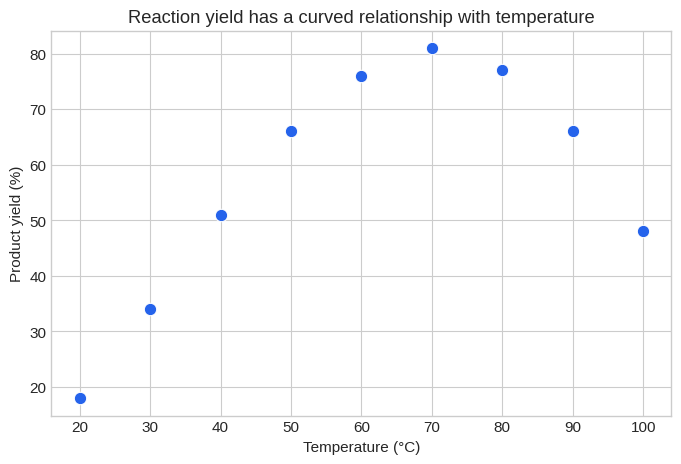

In [ ]:
# A tiny curved dataset: reaction temperature and product yield
reaction_data = pd.DataFrame({
    "temperature_c": [20, 30, 40, 50, 60, 70, 80, 90, 100],
    "yield_percent": [18, 34, 51, 66, 76, 81, 77, 66, 48]
})

X_curve = reaction_data[["temperature_c"]]
y_curve = reaction_data["yield_percent"]

display(reaction_data)

plt.scatter(X_curve["temperature_c"], y_curve,s=80, color=BLUE, edgecolor="white", linewidth=0.8)

plt.title("Reaction yield has a curved relationship with temperature")

plt.xlabel("Temperature (°C)")
plt.ylabel("Product yield (%)")
plt.show()

### When to Use Linear Regression

Use **Linear Regression** when:

- There is **one main feature** and the relationship with the target is approximately linear.
- You want a **simple and interpretable model**.
- You need a good **baseline model** for a regression problem.

**Example:** Predict exam score from study hours.


### When to Use Multiple Linear Regression

Use **Multiple Linear Regression** when:

- You have **multiple features** that may help predict the target.
- The relationship between the features and target is approximately linear.
- You want to understand the contribution of **different features** to the prediction.

**Example:** Predict exam score using study hours, sleep hours, and attendance.

### When to Use Polynomial Regression

Use **Polynomial Regression** when:

- The relationship between the feature and target is **curved rather than straight**.
- Linear Regression is too simple and **underfits** the data.
- You want to capture non-linear patterns while still using a linear regression model.

**Example:** Predict reaction yield from temperature when the yield first increases and then decreases.

## Try It Yourself

Now try applying the regression techniques we learned today to a **different real-world dataset**.

- Choose a dataset with a **continuous numerical target**.
- Identify the features (`X`) and target (`y`).
- Train a Linear Regression model.
- Evaluate the predictions using **MAE, RMSE, and R²**.
- Check whether Linear Regression is a reasonable model for the problem.
- If the relationship is curved, try **Polynomial Regression**.

**Think about:**  
> Can this real-world problem actually be solved using Linear Regression? Why or why not?

## Limitations of Linear Regression

Linear Regression works well when the target is a **continuous numerical value**.

However, it is not suitable for every problem.

For example:

- Predicting **exam score** → continuous value → Linear Regression ✓
- Predicting **house price** → continuous value → Linear Regression ✓
- Predicting **pass/fail** → two classes → Linear Regression ✗
- Predicting **spam/not spam** → two classes → Linear Regression ✗
- Predicting **disease/no disease** → two classes → Linear Regression ✗

## 14. Recap and Quick Questions

### End-to-End Regression Workflow

**Define the problem → Choose X and y → Split the data → Train → Predict → Evaluate → Interpret**

### Quick Check

1. **Why is this a regression problem?**  
   Because the target is a continuous numerical value.

2. **What does the slope tell us?**  
   The expected change in the predicted target for a one-unit increase in the feature.

3. **Why do we keep a test set?**  
   To evaluate the model on data it has not seen during training.

4. **What does a residual of zero mean?**  
   The prediction exactly matches the actual value.

5. **What does polynomial regression add?**  
   Additional features such as $x^2$, allowing the model to represent curved relationships.

6. **Why not always use a very high polynomial degree?**  
   Because the model may overfit the training data and perform poorly on new data.

### Final Takeaway

> **Linear Regression is a strong baseline for predicting continuous values.**

> **Multiple Linear Regression allows us to use multiple features.**

> **Polynomial features allow Linear Regression to model curved relationships.**

> **Always evaluate the model on unseen data.**